# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

Rebuilds the Week-4 baseline signal and the Week-5/6 model, but scores **every row honestly** using out-of-fold predictions (`GroupKFold` + `cross_val_predict`, grouped by client) rather than fitting on all data and scoring the same data — that would be in-sample scoring, the exact mistake Week 6 was about catching.

In [1]:
import pandas as pd, numpy as np, json, os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

# Week-4 baseline signal (CTR underperforms its position tier)
tier_ctr = df[df["impressions_90d"] >= 100].groupby("position_tier")["ctr"].mean()
df["expected_ctr_tier"] = df["position_tier"].map(tier_ctr)
eligible = (df["impressions_90d"] >= 200) & df["expected_ctr_tier"].notna()
gap = (df["expected_ctr_tier"] - df["ctr"]).clip(lower=0)
df["ctr_gap_score"] = np.where(eligible, gap * df["impressions_90d"], 0)

# Week-5/6 model, scored out-of-fold for every row (honest, not in-sample)
features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count", "engagement_rate"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

gkf = GroupKFold(n_splits=5)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
df["decline_score"] = cross_val_predict(rf, X, y, cv=gkf, groups=df["client_id"], method="predict_proba")[:, 1]

print(f"{len(df):,} rows scored | decline_score range: "
      f"{df['decline_score'].min():.2f}-{df['decline_score'].max():.2f}")

30,000 rows scored | decline_score range: 0.00-0.98


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
action_map = {
    "high_value_ctr_gap":       ("review_meta_and_snippet",  "high_value_ctr_gap"),
    "declining_low_ctr_signal": ("content_refresh_review",   "declining_low_ctr_signal"),
    "ctr_gap_stable":           ("monitor_ctr_gap",          "ctr_gap_stable"),
    "stale_but_visible":        ("manual_review_stale",      "stale_but_visible"),
}

def archetype(row):
    if row["ctr_gap_score"] > 0 and row["decline_score"] >= 0.6:
        return "high_value_ctr_gap"
    elif row["decline_score"] >= 0.6 and row["ctr_gap_score"] == 0:
        return "declining_low_ctr_signal"
    elif row["ctr_gap_score"] > 0 and row["decline_score"] < 0.6:
        return "ctr_gap_stable"
    elif row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_but_visible"
    else:
        return "no_action"

df["archetype"]   = df.apply(archetype, axis=1)
df["action"]      = df["archetype"].map(lambda a: action_map.get(a, (None, None))[0])
df["reason_code"] = df["archetype"].map(lambda a: action_map.get(a, (None, None))[1])
df["priority_score"] = df["decline_score"] * df["impressions_90d"]

queue = df[df["archetype"] != "no_action"].sort_values("priority_score", ascending=False).reset_index(drop=True)

print(f"Queue: {len(queue):,} of {len(df):,} pages get an action\n")
print("Archetype sizes:")
print(queue["archetype"].value_counts())
print()
print("Decline rate by archetype (sanity check: should separate from the 0.542 base rate):")
print(df.groupby("archetype")["is_declining_label"].mean().round(3))
print()
cols = ["content_id", "client_id", "archetype", "action", "reason_code",
        "decline_score", "ctr_gap_score", "impressions_90d", "priority_score"]
queue[cols].head(10)

Queue: 19,308 of 30,000 pages get an action

Archetype sizes:
archetype
high_value_ctr_gap          8187
declining_low_ctr_signal    5938
ctr_gap_stable              5179
stale_but_visible              4
Name: count, dtype: int64

Decline rate by archetype (sanity check: should separate from the 0.542 base rate):
archetype
ctr_gap_stable              0.547
declining_low_ctr_signal    0.599
high_value_ctr_gap          0.685
no_action                   0.399
stale_but_visible           1.000
Name: is_declining_label, dtype: float64



,content_id,client_id,archetype,action,reason_code,decline_score,ctr_gap_score,impressions_90d,priority_score
0,content_5fe46e04994d,client_4e07408562,high_value_ctr_gap,review_meta_and_snippet,high_value_ctr_gap,0.623333,111184.288695,517715,322709.016667
1,content_8c19996aa890,client_4e07408562,high_value_ctr_gap,review_meta_and_snippet,high_value_ctr_gap,0.620000,93767.338236,509252,315736.240000
2,content_2cb567c3c89b,client_6208ef0f77,high_value_ctr_gap,review_meta_and_snippet,high_value_ctr_gap,0.623333,21083.150457,497727,310249.830000
3,content_4c36c775b818,client_4e07408562,declining_low_ctr_signal,content_refresh_review,declining_low_ctr_signal,0.606667,0.000000,463103,280949.153333
4,content_1a9e894be2e2,client_19581e27de,ctr_gap_stable,monitor_ctr_gap,ctr_gap_stable,0.586667,51922.468319,416180,244158.933333
5,content_aaef01a50def,client_19581e27de,ctr_gap_stable,monitor_ctr_gap,ctr_gap_stable,0.400000,54172.154351,517109,206843.600000
6,content_b28d1efd668f,client_6208ef0f77,high_value_ctr_gap,review_meta_and_snippet,high_value_ctr_gap,0.623333,23604.709383,286608,178652.320000
7,content_db5989a78dd3,client_4e07408562,ctr_gap_stable,monitor_ctr_gap,ctr_gap_stable,0.493333,49958.145235,345111,170254.760000
8,content_8451fc6f034d,client_d029fa3a95,ctr_gap_stable,monitor_ctr_gap,ctr_gap_stable,0.583333,82766.496060,272144,158750.666667
9,content_b511d4bc4ad2,client_6208ef0f77,high_value_ctr_gap,review_meta_and_snippet,high_value_ctr_gap,0.766667,485.725545,205915,157868.166667


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this, for what:** a content editor with limited weekly review capacity, working down the queue to decide which pages get a title/meta rewrite, a fuller content refresh, or just a watch-list entry — the same decision framing from Week 1's research question, now backed by a validated model instead of a hand rule alone.

**Where it stops being valid:**
- **One portfolio, one snapshot.** This queue is built from 32 clients and one CSV snapshot — it says nothing about a client not represented in this data, and nothing about how these pages will look next quarter.
- **Proxy label, not observed outcome.** `is_declining_label` is a bucket computed from the current window (`trend_direction == 'down'`), not a future outcome — flagged since Week 2 and still true here. This queue tells you what's declining *now* by that definition, not what will decline next.
- **Decision-support, not a guarantee.** Per the claim ladder: this is cross-sectional, observational data with a validated out-of-sample ranking, not a controlled experiment. The honest claim is "these pages look worth reviewing first, because …", never "fixing these will increase traffic."
- **Cost/value asymmetry, unchanged since Week 2:** a false positive costs an editor an hour on a fine page; a false negative lets a real decline compound. That's why the queue is ranked by `decline_score × impressions_90d` — reach-weighted risk — rather than probability alone, so limited review hours go to the highest-stakes pages first.

In [3]:
print(f"Queue covers {len(queue):,} pages out of {len(df):,} total "
      f"({len(queue)/len(df)*100:.1f}%) — this is a shortlist, not a full-portfolio audit.")
print(f"Underlying client roster: {df['client_id'].nunique()} clients, one CSV snapshot.")

Queue covers 19,308 pages out of 30,000 total (64.4%) — this is a shortlist, not a full-portfolio audit.
Underlying client roster: 32 clients, one CSV snapshot.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting on any `review_meta_and_snippet` pick:**
- Is the CTR gap actually about the title/snippet, or is a competitor's rich result (review stars, a shopping carousel, a People-Also-Ask box) eating the clicks regardless of what the title says? A rewrite won't fix that — this exact failure mode showed up in Week 4's top-10 review (#2).
- Is the page already trending `up` despite the CTR gap? Rewriting a page that's actively recovering risks disrupting something that's already working — also a real Week-4 finding (#4), not hypothetical.
- Is low CTR actually driven by raw volume dominating the priority score rather than a genuine gap (Week 4's #9 pattern)? Check the `ctr_gap_score` magnitude, not just rank position.

**What should NEVER be automated:**
- **No auto-publishing content changes.** Every action in this queue is a *recommendation to review*, never a trigger to edit or republish a live page automatically.
- **No acting on `stale_but_visible`** as currently built — it has only a handful of rows (see Section 1 counts); a headline claim or automated action from a bucket this small is exactly what the claim-ladder rule says to report-n-or-drop, not act on.
- **No cross-client generalization without a human check.** The model was validated on 8 held-out clients (Week 5/6) — a brand-new client added to the portfolio is effectively cold-start and should get manual review before the model's score is trusted for them.
- **No treating `decline_score` as a probability guarantee.** It's a ranking signal from an out-of-fold cross-validated model, not a calibrated probability — useful for ordering, not for a sentence like "73% chance this page keeps declining."

In [4]:
# Concrete check: how many queue rows are in the too-small-to-trust archetype?
small_bucket = (queue["archetype"] == "stale_but_visible").sum()
print(f"stale_but_visible rows in the queue: {small_bucket} — too small to act on without manual review, per the no-go list above.")

# Concrete check: how many top-50 picks are pages already trending up (the Week-4 #4 pattern)?
top50 = queue.head(50)
trending_up_in_top50 = (top50["trend_direction"].str.lower() == "up").sum()
print(f"Top-50 picks already trending 'up': {trending_up_in_top50} — these need the human check above before acting.")

stale_but_visible rows in the queue: 4 — too small to act on without manual review, per the no-go list above.
Top-50 picks already trending 'up': 11 — these need the human check above before acting.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signals that the recommendations have gone stale, in plain terms:**
- **Base rate drift.** If the portfolio's overall decline rate moves meaningfully away from this snapshot's 0.542 (e.g., a seasonal shift or a big content push), the `decline_score ≥ 0.6` threshold used to build archetypes stops meaning what it meant when it was set — re-check the threshold, don't assume it still separates the same way.
- **Archetype size swings.** A sudden jump in `no_action` (fewer pages getting any recommendation) or a collapse in `high_value_ctr_gap` is worth investigating before trusting the queue — could be a real portfolio change, or could be a broken upstream data feed.
- **New client onboarded.** Per the no-go list, a new client is cold-start; monitor whether their pages cluster oddly in the queue (e.g., all `no_action`) before trusting scores for them.
- **Precision drift on a fresh holdout.** Re-run the Week-5/6 style client-grouped evaluation periodically (quarterly is reasonable given the panel's pace) — if precision@50 drops toward the dummy-classifier floor (0.580, from Week 5), that's the retrain trigger, not a calendar date.
- **Retrain, don't just re-score, when:** the feature distributions shift enough that `days_since_last_update`/`content_age_days` ranges move outside what the model was fit on, or when enough new labeled history accumulates that a time-aware split becomes possible instead of the current cross-sectional one — a genuinely stronger validation design than anything used so far.

In [5]:
# Quantify the monitoring baseline to compare future runs against
monitoring_baseline = {
    "snapshot_base_rate": round(float(df["is_declining_label"].mean()), 3),
    "archetype_counts": df["archetype"].value_counts().to_dict(),
    "queue_size": int(len(queue)),
    "total_rows": int(len(df)),
}
print("Monitoring baseline to compare future runs against:")
for k, v in monitoring_baseline.items():
    print(f"  {k}: {v}")

Monitoring baseline to compare future runs against:
  snapshot_base_rate: 0.542
  archetype_counts: {'no_action': 10692, 'high_value_ctr_gap': 8187, 'declining_low_ctr_signal': 5938, 'ctr_gap_stable': 5179, 'stale_but_visible': 4}
  queue_size: 19308
  total_rows: 30000


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exports the ranked queue (CSV, stays out of git per the leak-guard), the metrics JSON receipt (committed — this is what the paper's numbers trace back to), and one figure (committed to `work/figures/`).

Wrote work/outputs/content_action_queue.csv — 19,308 rows
Wrote work/outputs/w07_playbook_metrics.json


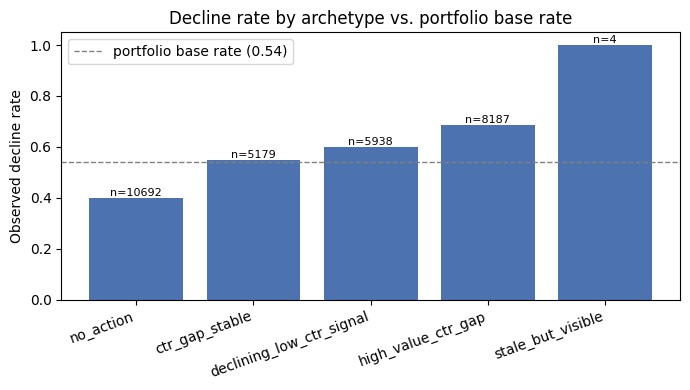

Wrote work/figures/archetype_decline_rates.png


In [6]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1) The ranked queue CSV (out of git by design — regenerates on every run)
export_cols = ["content_id", "client_id", "content_type", "position_tier", "trend_direction",
               "archetype", "action", "reason_code", "decline_score", "ctr_gap_score",
               "impressions_90d", "priority_score"]
queue[export_cols].to_csv("work/outputs/content_action_queue.csv", index=False)
print(f"Wrote work/outputs/content_action_queue.csv — {len(queue):,} rows")

# 2) Metrics JSON receipt (commit this — the paper's numbers trace back to it)
metrics = {
    "snapshot_base_rate": round(float(df["is_declining_label"].mean()), 3),
    "total_rows": int(len(df)),
    "queue_size": int(len(queue)),
    "n_clients": int(df["client_id"].nunique()),
    "archetype_counts": {k: int(v) for k, v in df["archetype"].value_counts().to_dict().items()},
    "archetype_decline_rate": {k: round(float(v), 3) for k, v in
                                df.groupby("archetype")["is_declining_label"].mean().to_dict().items()},
    "model_validation_source": "w06_validation_audit.ipynb: client-grouped precision@20=0.850, precision@50=0.660",
    "scoring_method": "GroupKFold(n_splits=5) out-of-fold predict_proba, grouped by client_id",
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/w07_playbook_metrics.json")

# 3) Figure: decline rate by archetype (commit this to work/figures/)
fig, ax = plt.subplots(figsize=(7, 4))
order = ["no_action", "ctr_gap_stable", "declining_low_ctr_signal", "high_value_ctr_gap", "stale_but_visible"]
rates = df.groupby("archetype")["is_declining_label"].mean().reindex(order)
counts = df["archetype"].value_counts().reindex(order)
bars = ax.bar(order, rates.values, color="#4C72B0")
ax.axhline(df["is_declining_label"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f"portfolio base rate ({df['is_declining_label'].mean():.2f})")
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"n={n}",
            ha="center", fontsize=8)
ax.set_ylabel("Observed decline rate")
ax.set_title("Decline rate by archetype vs. portfolio base rate")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/figures/archetype_decline_rates.png", dpi=150)
plt.show()
print("Wrote work/figures/archetype_decline_rates.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.